In [ ]:
pip install statsmodels

In [ ]:
# Prepare The Library
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load The Dataset
df = pd.read_csv('sample_data/data_emas.csv')

In [ ]:
# Clasify The Variables
# Variabel terikat
Y = df['gold_price']

# Variabel bebas
X = df[['inflation', 'interest', 'USD_rate']]

# Tambahkan konstanta (β0)
X = sm.add_constant(X)

In [ ]:
# Data dimension
print('harga_emas', df)

harga_emas            Periode  gold_price  inflation  interest  USD_rate
0     Januari 2013      462000     0.0457      5.75      9666
1    Februari 2013      467500     0.0531      5.75      9680
2       Maret 2013      460000     0.0590      5.75      9705
3           13-Apr      437500     0.0557      5.75      9723
4         Mei 2013      420000     0.0547      5.75      9786
..             ...         ...        ...       ...       ...
150      Juli 2025     1599809     0.0237      5.25     16286
151   Agustus 2025     1587626     0.0231      5.00     16309
152         25-Sep     1635791     0.0265      4.75     16523
153   Oktober 2025     1819979     0.0286      4.75     16604
154         25-Nov     1981275     0.0272      4.75     16705

[155 rows x 5 columns]


In [ ]:
# Cek missing value dengan fungsi isnull()
df.isnull().sum()

,0
Periode,0
gold_price,0
inflation,0
interest,0
USD_rate,0


In [ ]:
# Check apakah ada data numeric yang masih object, belum float64 ataupun int64
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Periode     155 non-null    object 
 1   gold_price  155 non-null    int64  
 2   inflation   155 non-null    float64
 3   interest    155 non-null    float64
 4   USD_rate    155 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 6.2+ KB


In [ ]:
# Rubah data numeric object menjadi float64
df['gold_price'] = pd.to_numeric(df['gold_price'], errors='coerce').astype('float64')
df['inflation'] = pd.to_numeric(df['inflation'], errors='coerce').astype('float64')
df['USD_rate'] = pd.to_numeric(df['USD_rate'], errors='coerce').astype('float64')

In [ ]:
# Check ulang semua data numeric sudah berubah menjadi float64 belum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Periode     155 non-null    object 
 1   gold_price  155 non-null    float64
 2   inflation   155 non-null    float64
 3   interest    155 non-null    float64
 4   USD_rate    155 non-null    float64
dtypes: float64(4), object(1)
memory usage: 6.2+ KB


In [ ]:
print('harga_emas', df)

harga_emas            Periode  gold_price  inflation  interest  USD_rate
0     Januari 2013    462000.0     0.0457      5.75    9666.0
1    Februari 2013    467500.0     0.0531      5.75    9680.0
2       Maret 2013    460000.0     0.0590      5.75    9705.0
3           13-Apr    437500.0     0.0557      5.75    9723.0
4         Mei 2013    420000.0     0.0547      5.75    9786.0
..             ...         ...        ...       ...       ...
150      Juli 2025   1599809.0     0.0237      5.25   16286.0
151   Agustus 2025   1587626.0     0.0231      5.00   16309.0
152         25-Sep   1635791.0     0.0265      4.75   16523.0
153   Oktober 2025   1819979.0     0.0286      4.75   16604.0
154         25-Nov   1981275.0     0.0272      4.75   16705.0

[155 rows x 5 columns]


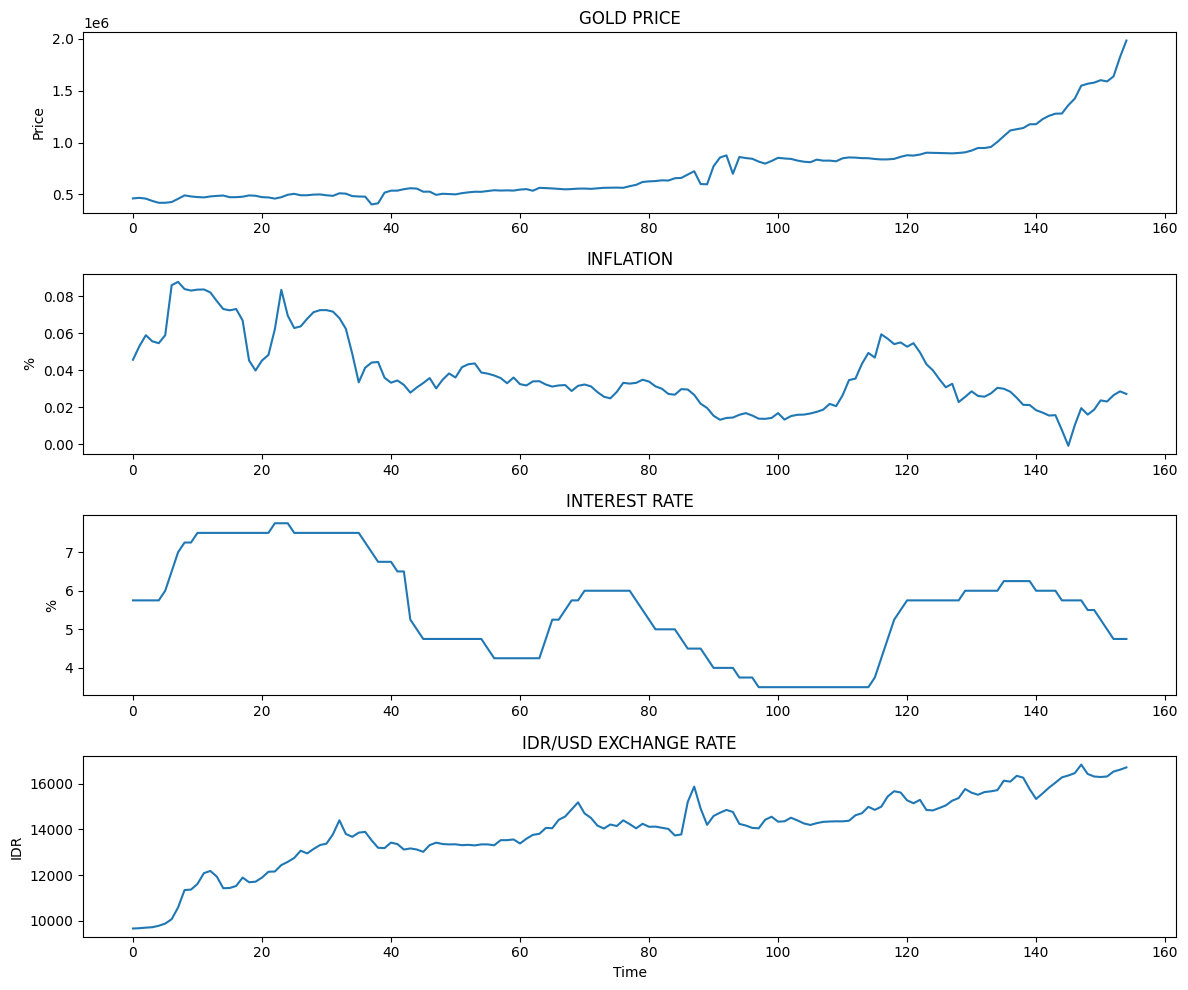

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 10))

# Harga emas
plt.subplot(4, 1, 1)
plt.plot(df.index, Y)
plt.title('GOLD PRICE')
plt.ylabel('Price')

# Inflasi
plt.subplot(4, 1, 2)
plt.plot(df.index, X['inflation'])
plt.title('INFLATION')
plt.ylabel('%')

# Suku bunga
plt.subplot(4, 1, 3)
plt.plot(df.index, X['interest'])
plt.title('INTEREST RATE')
plt.ylabel('%')

# Nilai tukar
plt.subplot(4, 1, 4)
plt.plot(df.index, X['USD_rate'])
plt.title('IDR/USD EXCHANGE RATE')
plt.ylabel('IDR')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,gold_price,inflation,interest,USD_rate
count,1.550000e+02,155.000000,155.000000,155.000000
mean,7.346612e+05,0.037776,5.527419,13991.361290
std,3.132095e+05,0.019617,1.302024,1586.468224
min,4.040000e+05,-0.000900,3.500000,9666.000000
25%,5.051875e+05,0.025350,4.500000,13312.000000
50%,5.795920e+05,0.032800,5.750000,14166.000000
75%,8.560050e+05,0.047600,6.250000,14986.000000
max,1.981275e+06,0.087900,7.750000,16827.000000


<Axes: xlabel='gold_price'>

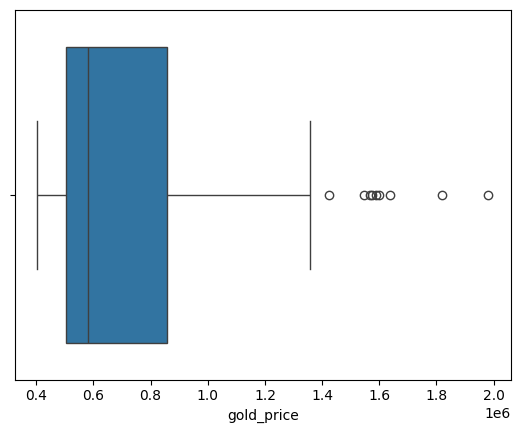

In [ ]:
sns.boxplot(x=df['gold_price'])

<Axes: xlabel='inflation'>

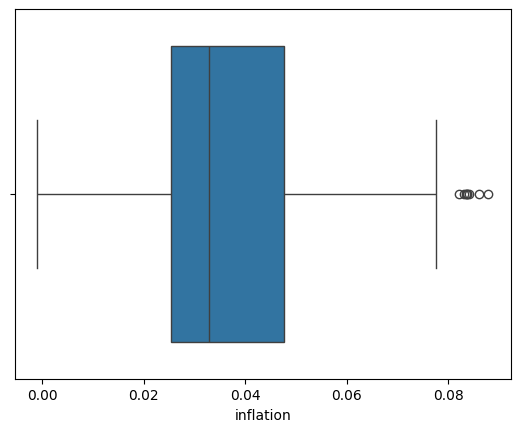

In [ ]:
sns.boxplot(x=df['inflation'])

<Axes: xlabel='interest'>

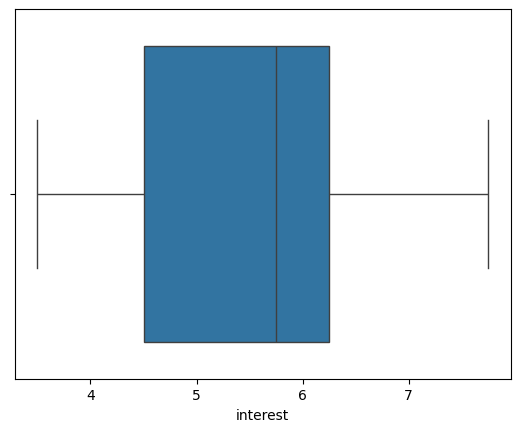

In [ ]:
sns.boxplot(x=df['interest'])

<Axes: xlabel='USD_rate'>

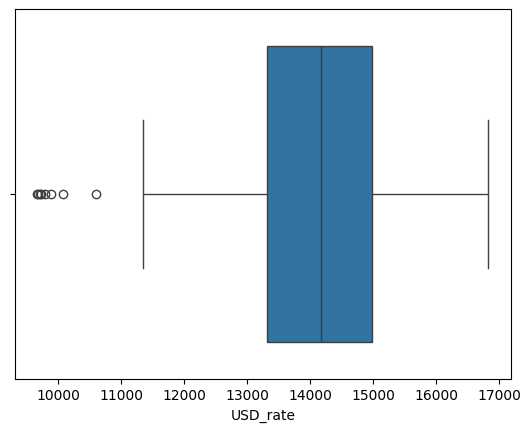

In [ ]:
sns.boxplot(x=df['USD_rate'])

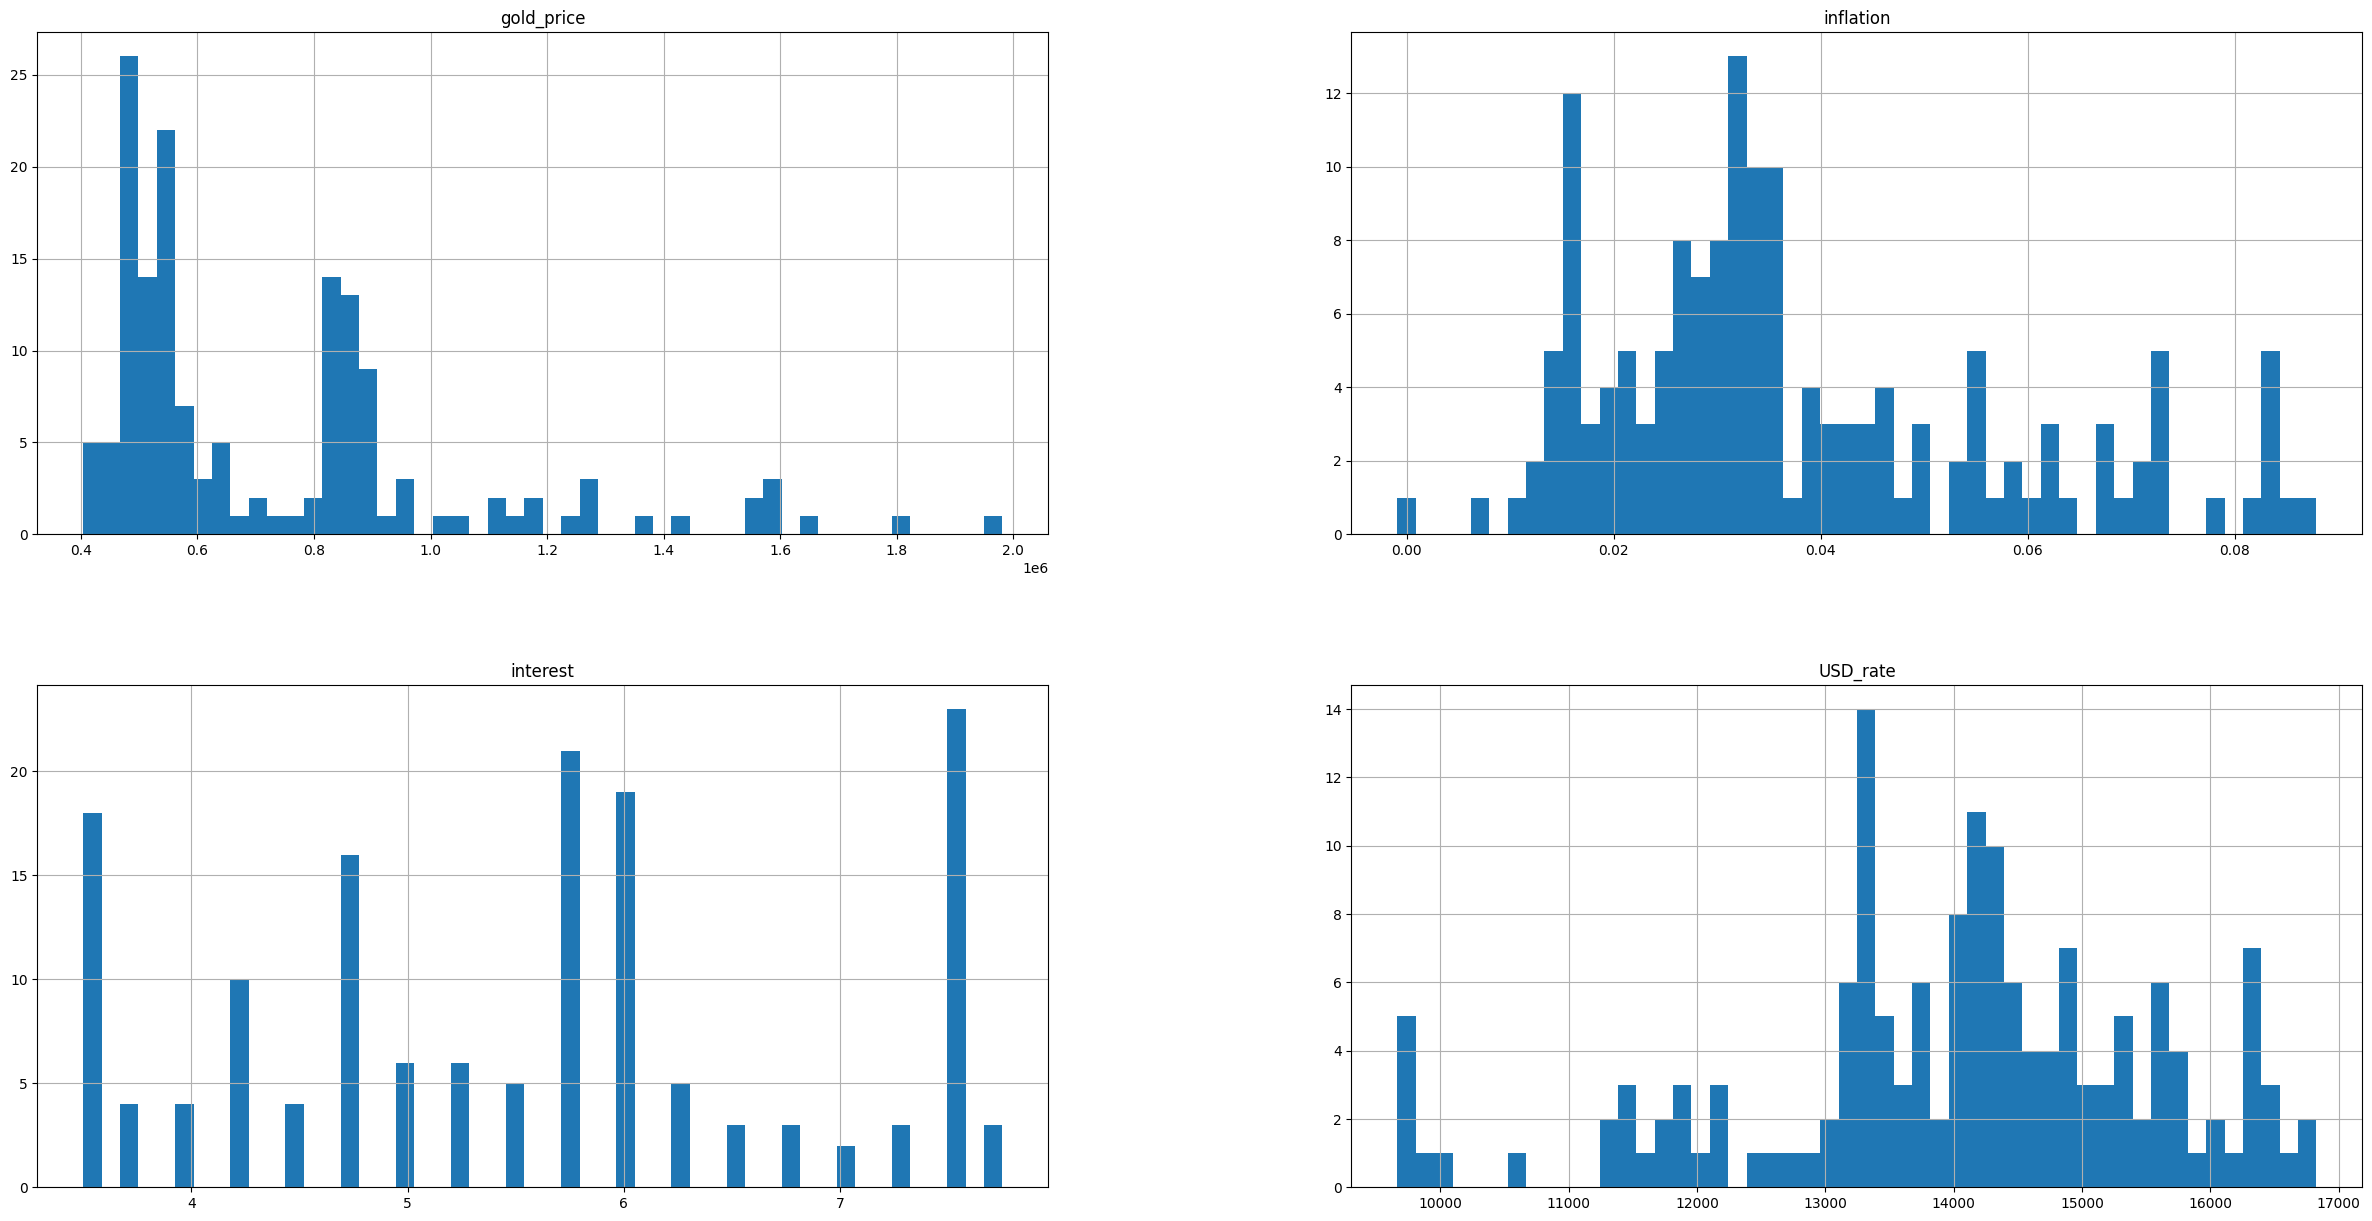

In [ ]:
df.hist(bins=50, figsize=(30,15))
plt.show()

In [ ]:
from scipy.stats import shapiro, skew, kurtosis

stat, p = shapiro(df['gold_price'])
print("p-value:", p)
print("skewness:", skew(df['gold_price']))
print("kurtosis:", kurtosis(df['gold_price']))

p-value: 6.924831395058657e-13
skewness: 1.6053275844405905
kurtosis: 2.4896947309014212


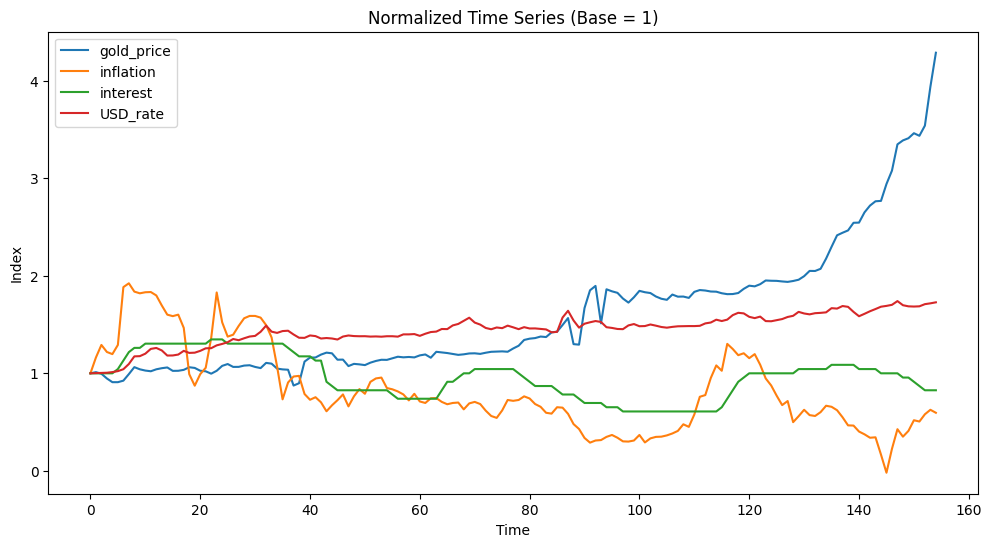

In [ ]:
# Merubah jadi economic-standard visualization (Index normalization)
df_norm = df[['gold_price', 'inflation', 'interest', 'USD_rate']] / df[['gold_price', 'inflation', 'interest', 'USD_rate']].iloc[0]

df_norm.plot(figsize=(12, 6))
plt.title('Normalized Time Series (Base = 1)')
plt.xlabel('Time')
plt.ylabel('Index')
plt.show()

In [ ]:
print(df.head())

         Periode  gold_price  inflation  interest  USD_rate
0   Januari 2013    462000.0     0.0457      5.75    9666.0
1  Februari 2013    467500.0     0.0531      5.75    9680.0
2     Maret 2013    460000.0     0.0590      5.75    9705.0
3         13-Apr    437500.0     0.0557      5.75    9723.0
4       Mei 2013    420000.0     0.0547      5.75    9786.0


In [ ]:
# Stationarity Test (ADF Test)
# VECM requires variables to be I(1)

import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import VECM

def adf_test(series, name):
    result = adfuller(series)
    print(f'ADF Test for {name}')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('---------------------------')

for col in df_numeric.columns:
    adf_test(df[col], col)

ADF Test for gold_price
ADF Statistic: 5.8178527072365
p-value: 1.0
---------------------------
ADF Test for inflation
ADF Statistic: -1.8365618698579023
p-value: 0.36246668701056495
---------------------------
ADF Test for interest
ADF Statistic: -1.7918337289011252
p-value: 0.38452349143681613
---------------------------
ADF Test for USD_rate
ADF Statistic: -2.3357998838145657
p-value: 0.16068155426571745
---------------------------


In [ ]:
# If variables are non-stationary, difference them:
# Test again to confirm they are I(1)

data_diff = df_numeric.diff().dropna()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

df_numeric = df.select_dtypes(include=[np.number])
for col in df_numeric.columns:
    adf_test(df_numeric[col],col)

ADF Test for gold_price
ADF Statistic: 5.8178527072365
p-value: 1.0
---------------------------
ADF Test for inflation
ADF Statistic: -1.8365618698579023
p-value: 0.36246668701056495
---------------------------
ADF Test for interest
ADF Statistic: -1.7918337289011252
p-value: 0.38452349143681613
---------------------------
ADF Test for USD_rate
ADF Statistic: -2.3357998838145657
p-value: 0.16068155426571745
---------------------------


In [ ]:
# If variables are non-stationary, difference them (SECOND ROUND):
# Test again to confirm they are I(1)

data_diff = df_numeric.diff().dropna()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

df_numeric = df.select_dtypes(include=[np.number])
for col in df_numeric.columns:
    adf_test(df_numeric[col],col)

ADF Test for gold_price
ADF Statistic: 5.8178527072365
p-value: 1.0
---------------------------
ADF Test for inflation
ADF Statistic: -1.8365618698579023
p-value: 0.36246668701056495
---------------------------
ADF Test for interest
ADF Statistic: -1.7918337289011252
p-value: 0.38452349143681613
---------------------------
ADF Test for USD_rate
ADF Statistic: -2.3357998838145657
p-value: 0.16068155426571745
---------------------------


In [ ]:
# Johansen Cointegration Test
# If trace statistic > critical value → cointegration exists
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen_test = coint_johansen(data_diff, det_order=0, k_ar_diff=1)

trace_stat = johansen_test.lr1
critical_values = johansen_test.cvt

print("Trace Statistics:", trace_stat)
print("Critical Values (95%):", critical_values[:,1])

Trace Statistics: [254.42023999 143.61416822  73.65730307  23.98815462]
Critical Values (95%): [47.8545 29.7961 15.4943  3.8415]


In [ ]:
# Estimate VECM Model

vecm_model = VECM(data_diff, k_ar_diff=1, coint_rank=1)
vecm_result = vecm_model.fit()

print(vecm_result.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation gold_price
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.gold_price    -0.4119      0.073     -5.635      0.000      -0.555      -0.269
L1.inflation  -7.637e+05   5.71e+05     -1.338      0.181   -1.88e+06    3.55e+05
L1.interest   -1.952e+04    1.8e+04     -1.082      0.279   -5.49e+04    1.58e+04
L1.USD_rate      36.9292     13.093      2.820      0.005      11.267      62.591
Det. terms outside the coint. relation & lagged endog. parameters for equation inflation
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.gold_price -3.425e-09   1.05e-08     -0.327      0.744    -2.4e-08    1.71e-08
L1.inflation     -0.1812      0.082     -2.215      0.027      -0.342      -0.021
L

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
# Interpret Key Results
# Long-run coefficients

print("Cointegration Vector (Beta):")
print(vecm_result.beta)

Cointegration Vector (Beta):
[[ 1.00000000e+00]
 [-1.31077744e+08]
 [-1.49181405e+06]
 [ 5.29793676e+03]]


In [ ]:
# Short-run dynamics:
print("Short-run coefficients (Alpha):")
print(vecm_result.alpha)

Short-run coefficients (Alpha):
[[-1.06617775e-02]
 [ 1.32950303e-09]
 [ 2.00023256e-08]
 [-1.73034781e-04]]


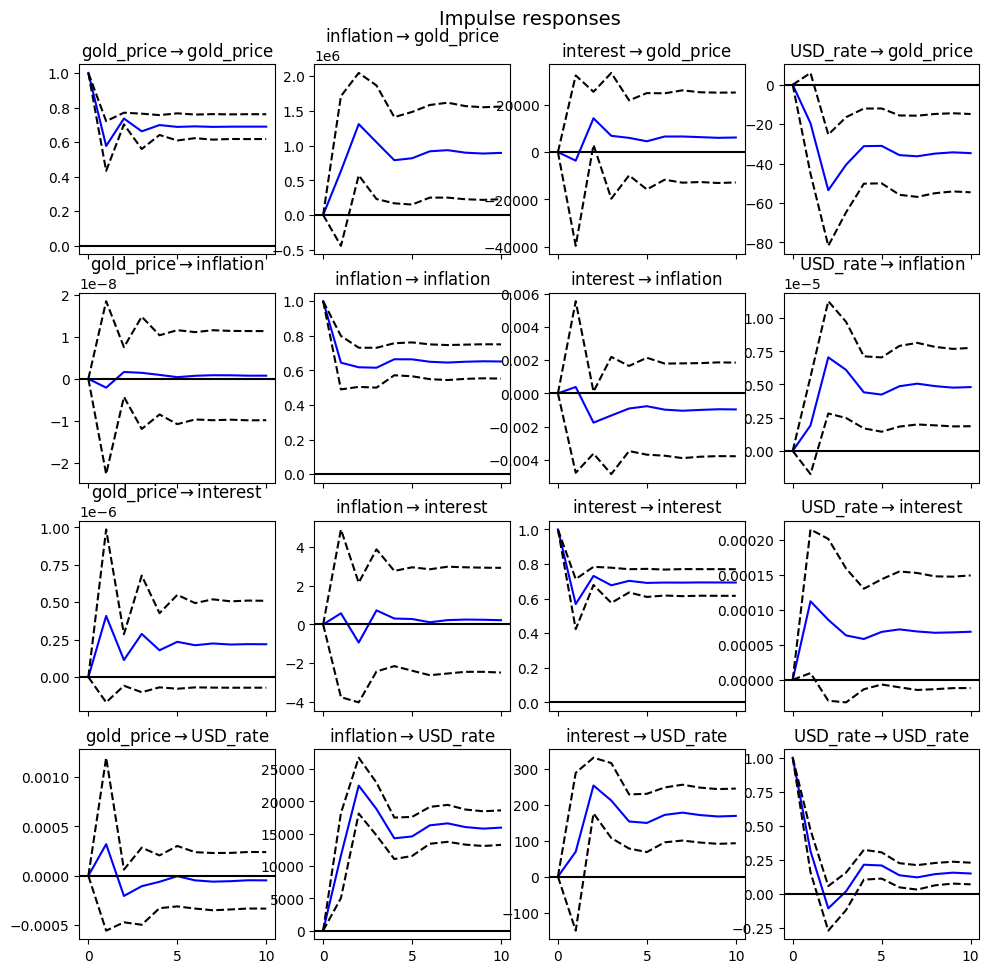

In [ ]:
# Impulse Response Function (Optional)
irf = vecm_result.irf(10)
irf.plot()
plt.show()

In [ ]:
# Important Notes
# Data frequency must be consistent (monthly recommended).
# Avoid mixing I(2) variables.
# Use log transformation for price variables (often improves stability):

data_diff['gold_price'] = np.log(df_numeric['gold_price'])
data_diff['USD_rate'] = np.log(df_numeric['USD_rate'])